In [19]:
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.array as da

In [23]:
ONI=pd.read_csv(r"C:\Users\paola\Tesis\01_Data\ONI\ONI.txt")


In [24]:
ONI

,Year\tDJF\tJFM\tFMA\tMAM\tAMJ\tMJJ\tJJA\tJAS\tASO\tSON\tOND\tNDJ
0,1950\t-1.5\t-1.3\t-1.2\t-1.2\t-1.1\t-0.9\t-0.5...
1,1951\t-0.8\t-0.5\t-0.2\t0.2\t0.4\t0.6\t0.7\t0....
2,1952\t0.5\t0.4\t0.3\t0.3\t0.2\t0.0\t-0.1\t0.0\...
3,1953\t0.4\t0.6\t0.6\t0.7\t0.8\t0.8\t0.7\t0.7\t...
4,1954\t0.8\t0.5\t0.0\t-0.4\t-0.5\t-0.5\t-0.6\t-...
...,...
71,2021\t-1.0\t-0.9\t-0.8\t-0.7\t-0.5\t-0.4\t-0.4...
72,2022\t-1.0\t-0.9\t-1.0\t-1.1\t-1.0\t-0.9\t-0.8...
73,2023\t-0.7\t-0.4\t-0.1\t0.2\t0.5\t0.8\t1.1\t1....
74,2024\t1.8\t1.5\t1.1\t0.7\t0.4\t0.2\t0.0\t-0.1\...


In [25]:
import pandas as pd

path = r"C:\Users\paola\Tesis\01_Data\ONI\ONI.txt"

# Leemos forzando separador en tabs reales o espacios
ONI = pd.read_csv(
    path,
    sep=r"\s+|\t+",   # espacios o tabs
    engine="python"
)

# Revisamos primeras filas y columnas
print(ONI.head())
print(ONI.columns)


   Year  DJF  JFM  FMA  MAM  AMJ  MJJ  JJA  JAS  ASO  SON  OND  NDJ
0  1950 -1.5 -1.3 -1.2 -1.2 -1.1 -0.9 -0.5 -0.4 -0.4 -0.4 -0.6 -0.8
1  1951 -0.8 -0.5 -0.2  0.2  0.4  0.6  0.7  0.9  1.0  1.2  1.0  0.8
2  1952  0.5  0.4  0.3  0.3  0.2  0.0 -0.1  0.0  0.2  0.1  0.0  0.1
3  1953  0.4  0.6  0.6  0.7  0.8  0.8  0.7  0.7  0.8  0.8  0.8  0.8
4  1954  0.8  0.5  0.0 -0.4 -0.5 -0.5 -0.6 -0.8 -0.9 -0.8 -0.7 -0.7
Index(['Year', 'DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO',
       'SON', 'OND', 'NDJ'],
      dtype='object')


In [26]:
ONI_long = ONI.melt(id_vars="Year", var_name="Season", value_name="ONI")

# Mapeo de trimestres deslizantes a un mes representativo
season_month = {
    "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4,
    "AMJ": 5, "MJJ": 6, "JJA": 7, "JAS": 8,
    "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12
}

ONI_long["month"] = ONI_long["Season"].map(season_month)
ONI_long["date"] = pd.to_datetime(dict(year=ONI_long["Year"], month=ONI_long["month"], day=15))

ONI_long = ONI_long.set_index("date").sort_index()


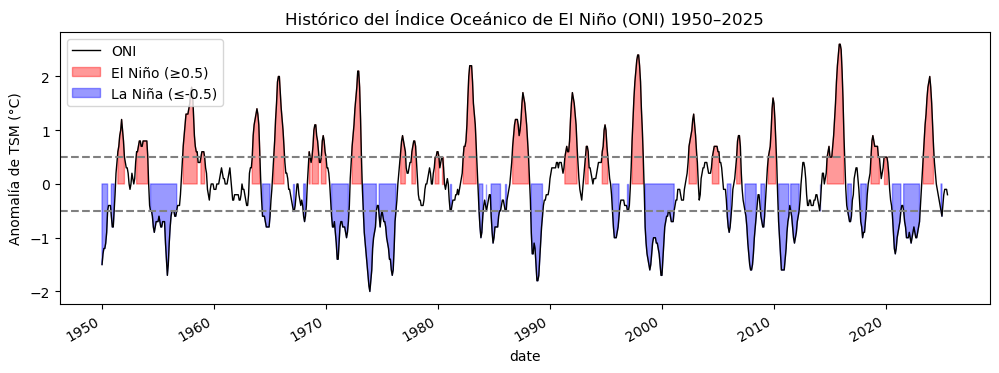

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ONI_long["ONI"].plot(ax=ax, color="k", lw=1)

# Colorear eventos Niño / Niña
ax.fill_between(ONI_long.index, ONI_long["ONI"], 0,
                where=ONI_long["ONI"]>=0.5, color="red", alpha=0.4, label="El Niño (≥0.5)")
ax.fill_between(ONI_long.index, ONI_long["ONI"], 0,
                where=ONI_long["ONI"]<=-0.5, color="blue", alpha=0.4, label="La Niña (≤-0.5)")

ax.axhline(0.5, color="gray", ls="--")
ax.axhline(-0.5, color="gray", ls="--")
ax.set_title("Histórico del Índice Oceánico de El Niño (ONI) 1950–2025")
ax.set_ylabel("Anomalía de TSM (°C)")
ax.legend()
plt.show()
